# Installtion 

In [ ]:
%%capture
!pip install numpy pandas matplotlib wordcloud plotly


#  Imports 

In [ ]:


# OS & Utilities
import os
import json
import re
from collections import Counter

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


# 1. Load the dataset


In [3]:
WIKI_MOVIES_PATH= "data\wiki_movie_plots_deduped.csv"



In [4]:
wiki_movies = pd.read_csv(WIKI_MOVIES_PATH)


In [5]:
# show random sample of 5 rows
wiki_movies.sample(5)

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
20060,1971,The Abominable Dr. Phibes,British,Robert Fuest,"Vincent Price, Joseph Cotton",horror/comedy,https://en.wikipedia.org/wiki/The_Abominable_D...,"Dr. Anton Phibes, a famous concert organist an..."
32607,2014,1: Nenokkadine,Telugu,Sukumar,"Mahesh Babu, Kriti Sanon",psychological action thriller,https://en.wikipedia.org/wiki/1:_Nenokkadine,Gautham is a schizophrenic Indian rock musicia...
11991,1993,Geronimo: An American Legend,American,Walter Hill,"Wes Studi, Jason Patric, Gene Hackman, Robert ...","biography, drama",https://en.wikipedia.org/wiki/Geronimo:_An_Ame...,The film loosely follows the events leading up...
1556,1933,Meet the Baron,American,Walter Lang,"Jack Pearl, Jimmy Durante, Edna May Oliver",comedy,https://en.wikipedia.org/wiki/Meet_the_Baron,A couple of bunglers (Jimmy Durante and Jack P...
11533,1990,Strike It Rich,American,James Scott,"Robert Lindsay, Molly Ringwald",comedy,https://en.wikipedia.org/wiki/Strike_It_Rich_(...,"In the 1950s, a young American woman living in..."


# 2. Data Exploration

## Dataset Shape


In [6]:

print("Dataset Shape:", wiki_movies.shape)


Dataset Shape: (34886, 8)


## Numerical Summary


In [7]:
wiki_movies.describe()

,Release Year
count,34886.000000
mean,1981.314252
std,27.815174
min,1901.000000
25%,1957.000000
50%,1988.000000
75%,2007.000000
max,2017.000000


## Dataset Info


In [8]:
wiki_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34886 entries, 0 to 34885
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Release Year      34886 non-null  int64 
 1   Title             34886 non-null  object
 2   Origin/Ethnicity  34886 non-null  object
 3   Director          34886 non-null  object
 4   Cast              33464 non-null  object
 5   Genre             34886 non-null  object
 6   Wiki Page         34886 non-null  object
 7   Plot              34886 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.1+ MB


# 3. DATA PREPROCESSING


## Missing Values

In [9]:

wiki_movies.isnull().sum()


Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                1422
Genre                  0
Wiki Page              0
Plot                   0
dtype: int64

- But we noticed that there are unknown values in the Genre column, and some Plot entries are shorter than 100 characters.

### Genre

In [10]:
# drop Genre column with unknown values
wiki_movies = wiki_movies[wiki_movies['Genre'] != 'unknown']

### Plot

In [11]:
# check for unknown values in Plot column
(wiki_movies['Plot']=="unknown").sum()


0

### Cast

In [12]:
wiki_movies["Cast"].isna().sum()

739

In [14]:
# drop cast with nan
wiki_movies = wiki_movies.dropna(subset=['Cast'])

## Director

In [15]:
wiki_movies["Director"].value_counts().keys()[0]

'Unknown'

- keep it as there important info in genre and plot


## Duplicate Rows


In [16]:
print(wiki_movies.duplicated().sum())


0


## Zero or negative values in columns


In [17]:
numerical_cols = wiki_movies.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [18]:
for col in numerical_cols:
    print(f"Number of Zeros in {col}: {(wiki_movies[col] == 0).sum()}")
    print(f"Number of Negative values in {col}: {(wiki_movies[col] < 0).sum()}")


Number of Zeros in Release Year: 0
Number of Negative values in Release Year: 0


## Outliers

In [19]:

for col in numerical_cols:
    Q1 = wiki_movies[col].quantile(0.25)
    Q3 = wiki_movies[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outliers = wiki_movies[(wiki_movies[col] < lower_bound) | (wiki_movies[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers detected")



Release Year: 0 outliers detected


##  Text preprocessing

### Genre

#### Basic Preprocessing

In [20]:
wiki_movies['Genre'] = wiki_movies['Genre'].astype(str).str.lower()
wiki_movies['Genre'] = wiki_movies['Genre'].str.strip()
wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(r'[-/,&;]+', '|', regex=True)


#### Fix compound genres

In [21]:

compound_fixes = {
    'actionadventure': 'action|adventure',
    'actioncomedy': 'action|comedy',
    'actiondrama': 'action|drama',
    'actionlove': 'action|reomance',
    'actionmasala': 'action|reomance',
    'actionchildren': 'action|children',
    'actionthriller': 'action|thriller',
    'fantasychildren': 'fantasy|children',
    'fantasycomedy': 'fantasy|comedy',
    'fantasyperiod': 'fantasy|period',
    'dramacomedy': 'drama|comedy',
    'dramathriller': 'drama|thriller',
    'comedydrama': 'comedy|drama',
    'comedyhorror': 'comedy|horror',
    'comedythriller': 'comedy|thriller',
    'comedysocial': 'comedy|social',
    'adventurecomedy': 'adventure|comedy',
    'animationdrama': 'animation|drama',
    'crimethriller': 'crime|thriller',
    'epichistory': 'epic|history',
    'gangsterthriller': 'gangster|thriller',
    'heistcomedy': 'comedy',
    'historydisaster': 'history|disaster',
    'warcomedy': 'war|comedy',
    'westerncomedy': 'western|comedy',
    'familydrama': 'family|drama',
    'horrorthriller': 'horror|thriller',
    'suspensethriller': 'suspense|thriller',
    'romanceaction': 'romance|action',
    'romancecomedy': 'romance|comedy',
    'romancehorror': 'romance|horror',
    'romancefiction': 'romance|fiction',
    'science_fictionchildren': 'science_fiction|children',
    'liveaction': 'live|action',
    'ancientcostume': 'history',
    'animationchildren': 'animation|children',
    'devotionalbiography': 'devotional|biography',
    'docufiction': 'documentary|fiction',
    'musicaliography': 'musical|biography',
    'romcom': 'romance|comedy',
    'rom|com': 'romance|comedy',
    'actionner': 'action',
    'fantay': 'fantasy',
    'familya': 'family',
    'famil|': 'family',
    'dramacomedysocial': 'drama|comedy|social',

}

for compound, fixed in compound_fixes.items():
    wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(compound, fixed, regex=False)


#### Genre mapping

In [22]:
# Genre mapping dictionary to correct genre variants
genre_mapping = {
    # Biography variants
    'bio-pic': 'biography',
    'biopic': 'biography',
    'biographical': 'biography',
    'biodrama': 'biography',
    'bio-drama': 'biography',
    'biographic': 'biography',
    'biography fim': 'biography',
    'biogtaphy': 'biography',

    # Animation variants
    'animated': 'animation',
    'anime': 'animation',
    '3-d': 'animation',
    '3d': 'animation',
    'computer animation': 'animation',
    'computeranimation': 'animation',

    # Historical
    'historical': 'history',
    'historic': 'history',

    # Romance
    'romantic': 'romance',
    'romanctic': 'romance',
    'rom-coms': 'romance',

    # Children
    "children's": 'children',

    # Comedy
    'comedey': 'comedy',

    # Science Fiction
    'sci-fi': 'science_fiction',
    'sci|fi': 'science_fiction',
    'sci fi': 'science_fiction',
    'science fiction': 'science_fiction',

    # Thriller
    'ttriller': 'thriller',
    'thriler': 'thriller',
    'triller': 'thriller',
    'psycho thriller,': 'psycho_thriller',

    # Adventure
    'adventures': 'adventure',

    # Martial Arts
    'kung fu': 'martial_arts',
    'kung-fu': 'martial_arts',
    'martial arts': 'martial_arts',
    'martial art': 'martial_arts',
    'gun fu': 'martial_arts',
    'samurai': 'martial_arts',
    'bruceploitation': 'martial_arts',

    # War
    'world war ii': 'war',
    'world war i': 'war',
    'wwii': 'war',
    'ww1': 'war',
    'wartime': 'war',
    'war-time': 'war',

    # Spy
    'spy film': 'spy',
    'espionage': 'spy',

    # Other mappings
    'anthology film': 'anthology',
    'avant-garde': 'avant_garde',
    'biker film': 'biker',
    'buddy cop': 'buddy',
    'buddy film': 'buddy',
    'coming of age': 'coming_of_age',
    'coming-of-age': 'coming_of_age',
    'slice of life': 'slice_of_life',
    'psychological': 'psycho',
    'true crime': 'crime',
    'j-horror': 'horror',
    'american football': 'sports',
    'tv miniseries': 'series',
    'television miniseries': 'series',
    'serial': 'series',
    'chanbara': 'chambara',
    'biblical': 'religious',
    'muslim': 'religious',
    'melodrama': 'drama',
    'dramatic': 'drama',
    'dramaa': 'drama',
    'dramedy': 'drama|comedy',
    'satirical': 'satire',
    'mockumentary': 'documentary',
    'periodic': 'period',
    'politics': 'political',
    'erotica': 'adult',
    'erotic': 'adult',
    'ero': 'adult',
    'homosexual': 'adult',
    'sexual': 'adult',
    'roman|porno': 'adult',
    'music': 'musical',
    'noir': 'crime |thriller',
    'heist': 'action',
    'superheroes': 'superhero',
    'supeheroes': 'superhero',
    'superheroe': 'superhero',
    'cbctv_miniseries': 'tv_miniseries',
    'martialarts': 'martial_arts',
    'historic': 'history',
    'sciencefiction': 'science_fiction',
    'comedy 2-reeler': 'comedy',
    'musical b': 'musical',
    '16 mm film': 'short',
    'love': 'romance',
    "rom com": "romance",
    "epic": "drama",
    "detective": "mystery",
    "shashank": "drama",
    "docudrama": "drama",
    "disaster" : "action",
    "tokusatsu" : "science_fiction",
    "masala" : "drama",
    "slasher" : "horror",
    "black comedy" : "black_comedy",
    "literary":"drama",
    'musicalalal' : "musical",
    "musicalal": "musical",
    "otional": "emotional",
    "ploitation": "exploitation",
    "superhadult": "supernatural",
    "shakespearean" : "drama",
}

for old_term, new_term in genre_mapping.items():
    wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(old_term, new_term, regex=False)


####   Remove unwanted patterns


In [23]:
unwanted_patterns = [
    # Citation and reference patterns
    r'\[not in citation given\]', r'\[140\]', r'\[144\]', r'\[9\]', r'\[.*\]',

    # Production and technical details
    r' \(30min\)', '16 mm', '16 mm film', ' v-cinema', r'\|direct-to-dvd',
    r'\|directtodvd', 'direct-to-dvd', '3-d', '3d', 'imax', 'viacom 18 motion pictures',
    'bholenath movies', 'cinekorn entertainment', 'yash raj films', 'colour|yellow|productions|eros|international',
    'movies by the mob', 'knkspl', 'british-german co-production', 'national film board',
    'nfb', 'cbc-tv', 'tv miniseries', 'stop-motion animation', 'clay animation',
    'computer animation', 'computer-animated', 'interactive cinema', 'student film',
    'bbc', 'bbc films', 'sf', 'p.o.w.', 'kaiju eiga', 'jidaigeki', 'jidai-geki',

    # Film descriptions and qualifiers
    r' \(film genre\)', r' \(aquatics\|swimming\)', r' \(shogi\|chess\)',
    r' \(volleyball\)', r' \(road bicycle racing\)', r' \(artistic\)', r' \(fiction\)',
    'set 4,000 years ago in the canadian arctic', 'based on radio serial',
    'on the early years of hitler', 'based on.*novel', 'adapted from.*play',
    'biography about montreal canadiens star', 'maurice richard',
    'yogesh dattatraya gosavi\'s directorial debut', 'dev|nusrat jahan',
    'biography of pioneering american photographer eadweard muybridge',
    'comedy-drama adaptation of the mordecai richler novel',
    'drama about child soldiers', 'drama loosely',
    r'\|6 separate stories', r'\|1 girl\|3 suitors', r'\|007',
    r'\|\(children\|poker\|karuta\)', r'\|–\|', r'\|produced\|.*',
    'inspired by true event', 'dance / thriller from the novel by bram stoker',
    'by j.g. ballard', 'by michel-marc bouchard', 'by alexandre goyette',
    'and screenplay by emma donoghue', 'produced with the',

    # Adaptation and production terms
    r'((\|produced\|).+)', r'((adaptation).+)', r'((adapted).+)', r'((adaptated).+)',
    r'(( based).+)', r'(( co-produced).+)', r'(( about).+)', r'(( on ).+)',

    # Generic film terms
    'films', 'film', 'movies', 'movie', 'remake', 'super hit movie',
    'critically acclaimed', 'cult film', 'sex', 'independent', 'reality',
    'youth', 'epic, patriotism', 'yeh saali zindagi', 'punk/avant_garde',
    'avant_garde', 'avant-garde', 'post-apocalyptic, zombie', 'august 25',
    'coming_of_age', 'coming of age', 'slice_of_life', 'slice of life','teen',

    # Actor and director names
    'dev', 'nusrat jahan', 'jeet', 'nusrat faria mazhar', 'shraddha das',
    'yash dasgupta', 'mimi chakraborty', 'mohanlal', 'mammootty',
    'allari naresh', 'sumanth', 'kamalinee mukherjee', 'rajiv kanakala',
    'ravi teja', 'anushka shetty', 'pawan kalyan', 'mahesh babu',
    'chiranjeevi', 'nagarjuna', 'jr. ntr', 'uday kiran',
    'srikanth', 'bhavana', 'keiji', 'balakrishna nandamuri', 'sneha', 'tabu',
    'charmy kaur', 'ileana d\'cruz', 'raja', 'bhoomika chawla', 's. p. balu',
    'bharath', 'arya', 'pooja', 'padmapriya', 'ken\'ichi maysuyama', 'koyuki',
    'shriya saran', 'nayantara', 'poonam bajwa', 'sivaji', 'krishna bhagavaan', 'ali',
    'indira amperiani', 'bhaskara s. narayanan', 'tapas paul', 'debashree roy',
    'yuen lai-kei', 'lee sin-je', 'chanchal chowdhury', 'masuma rahman', 'nabila partha barua',
    'biju menon', 'krishnashankar', 'samskruti shenoy', 'trisha krishnan', 'khushboo',
    'priyadarshini ram', 'viswendar reddy', 'radhika joshi', 'mohit ahlawat', 'priyanka kothari',
    'sunil', 'arti agarwal', 'siddharth', 'genelia d\'souza', 'prakash raj', 'jayasudha',
    'suhasini', 'sharwanand', 'shriya reddy', 'sameera reddy', 'sonu sood',
    'ajay', 'kota srinivasa rao', 'nedumudi venu', 'bharath gopi',
    'saloni aswani', 'siva balaji', 'reema sen', 'meera chopra', 'mukesh rishi',
    'reese witherspoon', 'scarlett johansson', 'ileana d\'cruz', 'prakash raj',
    'rajendra prasad', 'sindhu tolani', 'prabhas', 'trisha krishnan', 'charmme',
    'madhu sharma', 'shashank', 'bramhanandam', 'ravi babu',
    'rajasekhar', 'brahmanandam', 'kondavalasa lakshmana rao',
    'arjun', 'jagapati babu', 'jyothika', 'raghava lawrence', 'prabhu deva', 'prabhu a',
    'kamalini mukherjee', 'auli\'i cravalho', 'dwayne johnson',

    # Production companies and studios
    'dharma productions', 'red chillies entertainment', 'b.r films',
    'panorama studios', 'warner bros.', 'united artists',
    'paramount', 'warner home video', 'glukoza production',
    'silent hills studio', 'k9 films', 'd. ramanaidu', 'kalyani',
    'nadeem-shravan', 'chakravarthy musical hit',

    # Specific unwanted genres and types
    'imdb', 'pink', 'pink film', 'adult film', 'stoner film',
    'road movie', 'buddy film', 'buddy cop', 'buddy', 'gun fu', 'bruceploitation',
    'huangmei opera', 'counterculture', 'punk/avant-garde', 'musical b',
    'found footage', 'mockumentary', 'docufiction', 'spoof', 'parody',
    'anthology film', 'duology', 'trilogy', 'serial', 'short film',
    'feature animation', 'animated series', 'cartoon short', 'yakuza', 'mob',
    'superhadultes', 'superheroes', 'tokusatsu', 'magical girl', 'mecha',
    'kaiju', 'space opera', 'steampunk', 'neo-black', 'neo-noir',
    ' thriller', 'chambara','literary', "teen"

    # Country and location references
    'usa', 'can', ' usa', ' can', 'usa, can'

]
for pattern in unwanted_patterns:
    wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(pattern, '', regex=True)


#### Genre consolidation (reduce dimensionality)

In [24]:
consolidation_map = {
    'family': 'children',
    'martial_arts': 'action',
    'horror': 'thriller',
    'war': 'action',
    'adventure': 'action',
    'science_fiction': 'action',
    'western': 'action',
    'spy': 'action',
    'superhero': 'action',
    'suspense': 'action'
}

for old_genre, new_genre in consolidation_map.items():
    wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(old_genre, new_genre, regex=False)


#### Extra clean

In [26]:

wiki_movies["Genre"] = wiki_movies["Genre"].str.replace(r'\s+', '|', regex=True)
wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(r'\|+', '|', regex=True)  # Multiple pipes to single
wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(r'^\|+|\|+$', '', regex=True)  # Leading/trailing pipes
wiki_movies['Genre'] = wiki_movies['Genre'].str.replace(r'\s+', ' ', regex=True)  # Multiple spaces



#### post processing

In [27]:
def clean_genre_combo(genre_str):
    if pd.isna(genre_str):
        return None

    # split on |
    genres = [g.strip() for g in str(genre_str).split('|') if g.strip()]

    # remove duplicates inside same row
    genres = list(set(genres))

    # sort alphabetically to unify left|right vs right|left
    genres = sorted(genres)

    # join back
    return "|".join(genres)


wiki_movies["Genre"] = wiki_movies["Genre"].apply(clean_genre_combo)


In [28]:
corrections = {
    "musicalal": "musical",
    "comedy|musicalal": "comedy|musical",
    "fiction|science": "science_fiction",
    "otional": "emotional",
    "bio|pic": "biopic",
    "comedy|dark": "dark_comedy",
    "ploitation": "exploitation",
    "action|afri": "african_action",
    "superhadult": "supernatural"
}

def correct_spelling(s):
    if s in corrections:
        return corrections[s]
    return s



wiki_movies["Genre"] = wiki_movies["Genre"].apply(correct_spelling)


In [29]:
# Remove rows with empty genres
wiki_movies = wiki_movies[wiki_movies['Genre'].str.len() > 0]

In [30]:
## filter any catgeroy less then 15 in count
genre_counts = wiki_movies['Genre'].value_counts()
genre_counts = genre_counts[genre_counts >= 50]
# drop genres less then 15
wiki_movies = wiki_movies[wiki_movies['Genre'].isin(genre_counts.index)]


In [31]:
# split 
wiki_movies['Genre_List'] = wiki_movies['Genre'].str.split('|')


In [35]:
for i in wiki_movies['Genre'].value_counts().keys():
    print(i, wiki_movies['Genre'].value_counts()[i])

drama 6088
comedy 4439
action 4076
thriller 2174
romance 1001
comedy|romance 678
crime 638
comedy|drama 636
crime|drama 581
musical 468
action|drama 443
animation 420
drama|romance 408
crime|thriller 365
mystery 332
action|comedy 324
children 251
comedy|musical 245
biography 218
fantasy 205
children|drama 147
action|romance 136
comedy|thriller 129
biography|drama 112
comedy|crime 109
action|thriller 107
documentary 88
drama|history 85
history 82
drama|musical 72
series 70
action|fantasy 63
action|crime 60
supernatural 58
comedy|short 57
drama|thriller 57
comedy|drama|romance 55
action|crime|drama 55
black_comedy 52


### Plot

In [32]:
def clean_text(text):
    if not isinstance(text, str):
        return ''

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s.,!?-]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text


wiki_movies['Plot_Clean'] = wiki_movies['Plot'].apply(clean_text)
wiki_movies = wiki_movies[wiki_movies['Plot_Clean'].str.len() >= 50]



In [37]:
# save clean wiki_movies to csv
wiki_movies.to_csv("data\clean_wiki_movies.csv", index=False)

# Exploratory  data analysis

## HELPER FUNCTIONS
- extract_names
- split_genre_names

In [33]:
def extract_names(director_string):
    blacklist = ["unknown", "none", "jr.", "sr"]
    directors = [d.strip() for d in director_string.split(',') if d.strip().lower() not in blacklist]
    return [d for d in directors if d and d.lower() != 'unknown']

In [34]:

def split_genre_names(genre_string):
    genres = [g.strip() for g in genre_string.split('|')]
    return [g for g in genres if g]

##  Process all objects

In [35]:

all_genres = []
for genres in wiki_movies['Genre']:
        all_genres.extend([g.strip() for g in genres.split('|')])

genre_counts = pd.Series(all_genres).value_counts()

all_cast = []
for cast in wiki_movies['Cast']:
    cast_names = extract_names(cast)
    all_cast.extend(cast_names)

all_directors = []
for director in wiki_movies['Director']:
    director_names = extract_names(director)
    all_directors.extend(director_names)

# Count occurrences
cast_counts = Counter(all_cast)
director_counts = Counter(all_directors)

# Get top entities for visualizations
top_origins = wiki_movies['Origin/Ethnicity'].value_counts().head(5).index
top_genres = genre_counts.head(5).index
top_10_directors = [d for d, _ in director_counts.most_common(10)]
top_15_actors = [a for a, _ in cast_counts.most_common(15)]

## BASIC DISTRIBUTION VISUALIZATIONS


In [36]:

#  Distribution of movies by release year
fig_year = px.histogram(wiki_movies, x='Release Year',
                        title='Distribution of Movies by Release Year',
                        nbins=100)
fig_year.update_layout(xaxis_title='Release Year', yaxis_title='Number of Movies')
fig_year.show()

In [37]:

#  Distribution of movies by origin/ethnicity (top 15)
origin_counts = wiki_movies['Origin/Ethnicity'].value_counts().head(15)
fig_origin = px.bar(x=origin_counts.index, y=origin_counts.values,
                    title='Top 15 Movie Origins/Ethnicities',
                    labels={'x': 'Origin/Ethnicity', 'y': 'Number of Movies'},
                    color=origin_counts.values,)
fig_origin.update_layout(xaxis_title='Origin/Ethnicity', yaxis_title='Number of Movies')
fig_origin.show()


In [38]:
#  Distribution of movies by genre (top 15)
fig_genre = px.bar(x=genre_counts.head(15).index, y=genre_counts.head(15).values,
                  title='Top 15 Movie Genres',
                  labels={'x': 'Genre', 'y': 'Number of Movies'},
                  color=genre_counts.head(15).values,)
fig_genre.update_layout(xaxis_title='Genre', yaxis_title='Number of Movies')
fig_genre.show()

## TIME-BASED VISUALIZATIONS

In [39]:
#  Timeline of movie production by top origins

df_top_origins = wiki_movies[wiki_movies['Origin/Ethnicity'].isin(top_origins)]
fig_timeline = px.histogram(df_top_origins, x='Release Year', color='Origin/Ethnicity',
                           title='Timeline of Movie Production by Top 5 Origins',
                           barmode='overlay')
fig_timeline.update_layout(xaxis_title='Release Year', yaxis_title='Number of Movies')
fig_timeline.show()


In [45]:
# Genre distribution over time (top 5 genres)
genre_year_data = []
for _, row in wiki_movies.iterrows():
    for genre in row['Genre'].split('|'):
        genre = genre.strip()
        if genre in top_genres:
            genre_year_data.append({
                    'Genre': genre,
                    'Release Year': row['Release Year']
                })

genre_year_df = pd.DataFrame(genre_year_data)
fig_genre_time = px.histogram(genre_year_df, x='Release Year', color='Genre',
                             title='Evolution of Top 5 Genres Over Time',
                             nbins=50,
                             barmode='stack')
fig_genre_time.update_layout(xaxis_title='Release Year', yaxis_title='Number of Movies')
fig_genre_time.show()

## DIRECTOR ANALYSIS


In [46]:
#  Top directors by number of movies (top 15)
top_directors_df = pd.DataFrame(director_counts.most_common(15), columns=['Director', 'Movie Count'])
fig_director = px.bar(top_directors_df, x='Director', y='Movie Count',
                     title='Top 15 Directors by Number of Movies',
                     labels={'Director': 'Director Name', 'Movie Count': 'Number of Movies'},
                     color='Movie Count')

fig_director.update_layout(xaxis_title='Director', yaxis_title='Number of Movies')
fig_director.update_xaxes(tickangle=45)
fig_director.show()

In [56]:
#  Genre Distribution for Top Directors
director_genre_data = []
for _, row in wiki_movies.iterrows():
    directors = extract_names(row['Director'])
    genres = split_genre_names(row['Genre'])
    for director in directors:
        if director in top_10_directors:
            for genre in genres:
                if genre:
                    director_genre_data.append({
                        'Director': director,
                        'Genre': genre
                    })



director_genre_df = pd.DataFrame(director_genre_data)
genre_counter = Counter([item['Genre'] for item in director_genre_data])
top_genres_for_directors = [g for g, _ in genre_counter.most_common(10)]

filtered_director_genre = director_genre_df[
        director_genre_df['Genre'].isin(top_genres_for_directors)
]

director_genre_pivot = filtered_director_genre.groupby(['Director', 'Genre']).size().reset_index(name='Count')
director_genre_matrix = director_genre_pivot.pivot(index='Director', columns='Genre', values='Count').fillna(0)

fig_heatmap = px.imshow(
        director_genre_matrix,
        title='Genre Distribution for Top 10 Directors',
        labels=dict(x="Genre", y="Director", color="Number of Movies"),
        color_continuous_scale='Viridis',
        aspect="auto",
        text_auto=True
)
fig_heatmap.update_layout(height=600, width=900)
fig_heatmap.show()


##  ACTOR ANALYSIS


In [48]:
# 9. Top 20 Most Prolific Actors
top_cast_df = pd.DataFrame(cast_counts.most_common(20), columns=['Actor', 'Movie Count'])
fig_cast = px.bar(top_cast_df, x='Actor', y='Movie Count',
                 title='Top 20 Most Prolific Actors',
                 labels={'Actor': 'Actor Name', 'Movie Count': 'Number of Movies'},
                 color='Movie Count',
                 )
fig_cast.update_layout(xaxis_title='Actor Name', yaxis_title='Number of Movies')
fig_cast.update_xaxes(tickangle=45)
fig_cast.show()


## COLLABORATION ANALYSIS

In [ ]:
# Count top collaborations 
top_collabs = Counter(
    (d, a)
    for _, row in wiki_movies.iterrows()
    for d in extract_names(row['Director'])
    for a in extract_names(row['Cast'])
).most_common(20) 


# Unpack the collaboration pairs and their counts
collab_pairs, values = zip(*top_collabs)

# Create clear labels for each bar (e.g., "Director → Actor")
bar_labels = [f"{d} → {a}" for (d, a) in collab_pairs]



# Create a horizontal bar chart
fig = go.Figure(data=[
    go.Bar(
        x=values,            
        y=bar_labels,       
        orientation='h',     
    )
])

fig.update_layout(
    title_text="Top 20 Director-Actor Collaborations",
    xaxis_title="Number of Collaborations",
    yaxis_title="",
    yaxis_categoryorder='total ascending',
    template='plotly_white',
)

fig.show()

In [51]:


# 12. Actor Co-occurrence Network
actor_pairs = []
for _, row in wiki_movies.iterrows():
    actors = extract_names(row['Cast'])
    for i in range(len(actors)):
        for j in range(i+1, len(actors)):
            pair = tuple(sorted([actors[i], actors[j]]))
            actor_pairs.append(pair)

actor_pair_counts = Counter(actor_pairs)
top_actor_pairs = actor_pair_counts.most_common(10)

actor_pair_labels = []
for (actor1, actor2), count in top_actor_pairs:
    a1_short = actor1.split()[-1] if len(actor1.split()) > 1 else actor1[:15]
    a2_short = actor2.split()[-1] if len(actor2.split()) > 1 else actor2[:15]
    label = f"{a1_short} & {a2_short}"
    actor_pair_labels.append(label)

actor_pair_df = pd.DataFrame({
    'Actor Pair': actor_pair_labels,
    'Full Names': [f"{a1} & {a2}" for (a1, a2), _ in top_actor_pairs],
    'Movies Together': [count for _, count in top_actor_pairs]
})

fig_actor_pairs = px.bar(
    actor_pair_df,
    x='Actor Pair',
    y='Movies Together',
    title='Top 10 Actor Collaborations',
    labels={'Actor Pair': 'Actor Pair (Last Names)', 'Movies Together': 'Number of Movies Together'},
    color='Movies Together',
    color_continuous_scale='Plasma',
    hover_data=['Full Names']
)
fig_actor_pairs.update_layout(
    xaxis_title='Actor Pair',
    yaxis_title='Number of Movies Together',
    xaxis_tickangle=-45,
)
fig_actor_pairs.show()

## ADDITIONAL VISUALIZATIONS

In [50]:


#  Sunburst chart of Origin/Ethnicity and Genre
origin_genre_data = []
for _, row in wiki_movies.iterrows():
        for genre in row['Genre'].split('|'):
            genre = genre.strip()
            origin_genre_data.append({
                'Origin/Ethnicity': row['Origin/Ethnicity'],
                'Genre': genre
            })

origin_genre_df = pd.DataFrame(origin_genre_data)
filtered_origin_genre = origin_genre_df[
    (origin_genre_df['Origin/Ethnicity'].isin(top_origins)) &
    (origin_genre_df['Genre'].isin(top_genres))
]

fig_sunburst = px.sunburst(
    filtered_origin_genre,
    path=['Origin/Ethnicity', 'Genre'],
    title='Distribution of Top Genres within Top Origins',
)
fig_sunburst.show()

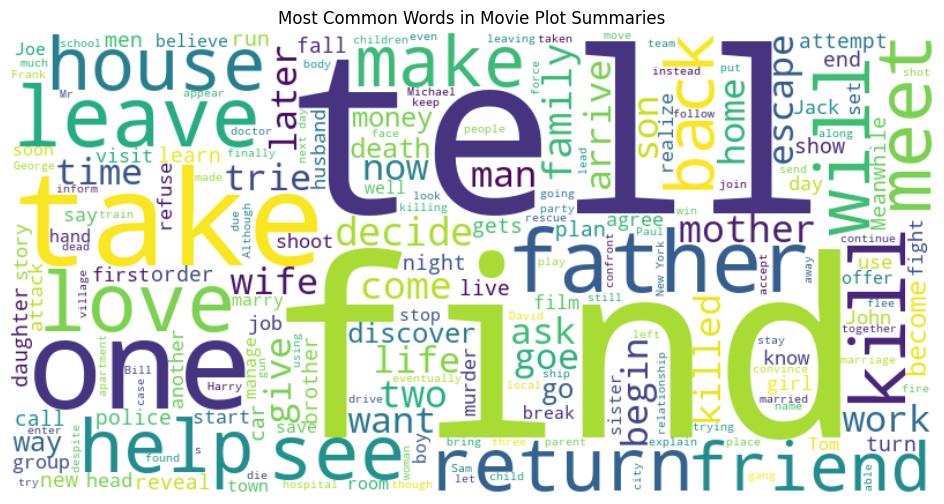

In [84]:
#  Word cloud of plot summaries
all_plots = ' '.join(wiki_movies['Plot'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_plots)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Movie Plot Summaries')
plt.show()